# Leçon 2: Python, introduction à sympy , quelques calculs de base et graphes symboliques


#### Important:

Dans l'utilisation du module sympy, il est important de noter que lorsqu'on fait un appel à une fonction mathématique qui fait partie du module sympy, comme sin, cos, exp, etc... ces fonctions n'ont pas nécessairement les mêmes comportements que les mes fonctions dans un autre module (par exemple **math** ou **numpy**), c'est donc une bonne pratique d'importer les modules en leur donnant un surnom comme **sp** pour sympy, **np** pour numpy , etc... Ainsi l'appel d'un sinus sur une variable symbolique par **sp.sin(x)** et sin(45) auront chacun le résultat attendu.

Étudiez les trois exemples suivants afin de bien comprendre le comportement des opérations sin(x)

In [17]:
import sympy as sp
from math import *
from IPython.display import *
%matplotlib inline
sp.init_printing(use_latex=True)
x=sp.symbols('x')
ysymbolique=sp.sin(x)
x = 45
ynumerique=sin(x)
display(ysymbolique)
display(ynumerique)


In [18]:
from sympy import *
from IPython.display import *
x=symbols('x')
ysymbolique=sin(x)
display(ysymbolique)

In [19]:
import sympy as sp
from math import *
from IPython.display import *
x=sp.symbols('x')
ysymbolique=sp.sin(x)
display(ysymbolique)
yespere=sin(x)

TypeError: can't convert expression to float

Pourquoi cette erreur?

*La variable x est symbolique, et la fonction sin est prise dans le module maths, alors elle s'attend à recevoir un nombre réel (float). Il y a donc erreur. Le message d'erreur est très détaillé et donne la ligne 7 comme source et la ligne 226 du package sympy (car x est défini comme symbole de sympy)*



### Utilisation du calcul symbolique pour solutionner un système d'équations linéaires

Le package sympy est utilisé

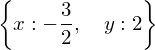

In [20]:
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
# active le module de calcul symbolique, et la ligne suivante:
x,y=sp.symbols('x,y')
# définit x et y comme variables algébriques symboliques.
# on définit ensuite les deux équations à résoudre
eq1= 2*x+  y+1
eq2=-4*x-5*y+4
# et on solutionne
solution=sp.solve((eq1,eq2),x,y)
# comme dans la fenetre de commande de matlab, on peut faire écho de la solution:
solution

Petite note: dans l'exemple précédent sympy a créé un ***dictionnaire*** qui contient la solution. Les variables x et y sont les *clefs* . Vous n'avez pas besoin de connaître les *dictionnaires* pour programmer adéquatement en python, cependant leurs propriétés sont très intéressantes. Ces *dictionnaires* réfèrent à leur contenu par clef et non par numéro. Ainsi pour l'exemple précédent:

In [21]:
from IPython.display import *
sp.init_printing(use_latex=True)
display(solution[x],solution[y])
print ('solution[0] et solution[1]) n''existent pas dans le cas d''un dictionnaire')
print(' On réfère plutôt à la clef (x et y dans ce cas)')

solution[0] et solution[1]) nexistent pas dans le cas dun dictionnaire
 On réfère plutôt à la clef (x et y dans ce cas)


Vous avez vu comment solutionner un système de deux équations linéaires à deux inconnues, on aurait pu aussi faire directement comme ceci, beaucou plus rapidement. Remarquez qu'on fait imprimer ici le type de la 'solution'.

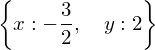

dict

In [22]:
solution=sp.solve((2*x+  y+1,-4*x-5*y+4),x,y)
display(solution)
display(type(solution))

Les racines d'un polynôme sont trouvées de la même façon. Remarquez qu'ici la solution retournée par sp.solve n'est pas un dictionnaire mais une **_liste_**, donc addressable avec la méthode [0] et [1] pour **solution** et directement dans z1 et z2 dans la première méthode.

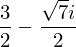

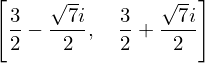

list

In [23]:
[z1,z2]=sp.solve(x**2-3*x+4)
display(z1)
solution=sp.solve(x**2-3*x+4)
display(solution)
display(type(solution))

i est utilisée pour la partie complexe:

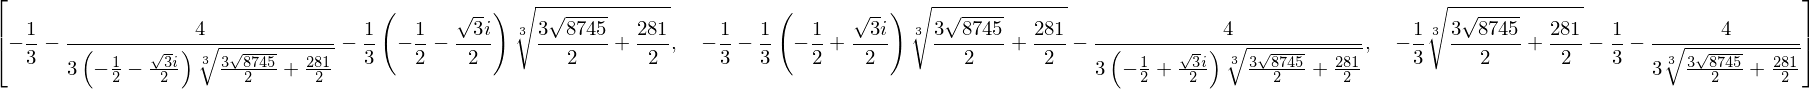

In [24]:
from IPython.display import *
sp.init_printing(use_latex=True)
racines=sp.solve(x**3+x**2-x+10)
#
# ici j'utilise la fonction display qui affichera en LaTeX
# J'ai fait la commande
#   from IPython.display import * 
# et sp.init_printing(use_latex=True)
# plus haut, j'ai donc accès à cet outil de formattage supérieur. Comparez avec la cellule 
# plus bas
#
display(racines)

racines est une liste qui contient les 3 racines de la cubique ci-haut. Contrairement à Matlab, la numérotation python commence à 0. La première racine est donc:

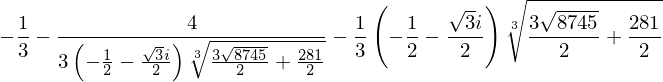

In [25]:
display(racines[0])

La forme, si vous êtes habitués à utiliser matlab symbolique, est un peu lourde et on peut utiliser une méthode pour simplifier la notation.

In [26]:
racines[0].evalf()

### sympy permet aussi de tracer des fonctions sous forme symbolique. La fonction plot de sympy évalue la fonction dans l'intervalle demandé en adaptant au besoin l'espacement des points.

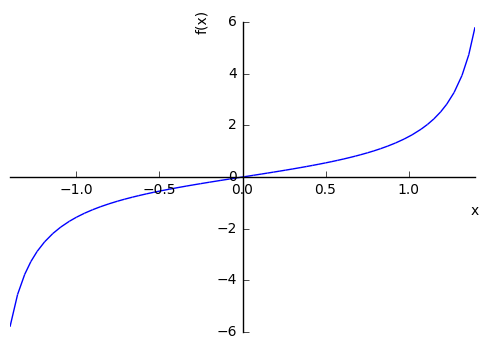

In [27]:
from sympy import plot,tan
x=sp.symbols('x')
plot(tan(x),(x,-1.4,1.4))

##### Dans l'exemple ci-haut, remarquez que le graphe (plot) provient du package sympy, donc il est conçu pour travailler avec des valeurs symboliques (un peu comme ezplot sur matlab) ainsi on doit utiliser les fonctions définies dans le package sympy.
##### Ceci illustre une particularité de python, les fonctions mathématiques usuelles (sin, exp, cos, etc...) sont définies dans différents packages et peuvent (doivent) avoir des comportements différents. Le sin du package numpy , du package math, ou celui du package sympy ne sont pas complètement équivalents car ils prennent des arguments différents. Ainsi il est usuel sous python d'importer les packages en leur donnant un surnom afin de bien savoir à quelle fonction on a affaire. Ainsi si on réécrit l'exemple ci-haut:

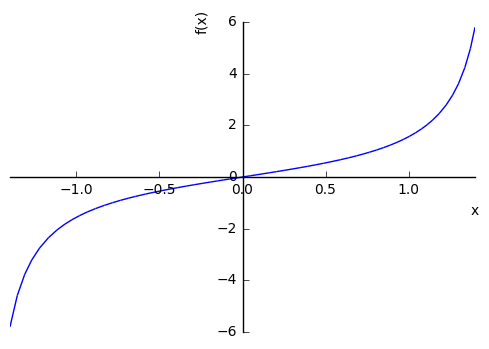

In [28]:
import sympy as sp
x=sp.symbols('x')
plot(sp.tan(x),(x,-1.4,1.4))

Ainsi on est certain d'utiliser la fonction correspondant au package voulu. On utilisera préférentiellement par exemple: import numpy as np ou import matplotlib.pyplot as plt
à partir de maintenant, les packages seront toujours utilisés avec cette technique.
Reprenons le cas des racines de polynômes et couplons le graphe à la recherche des racines:

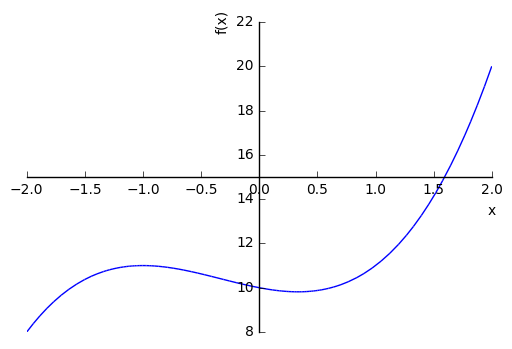

In [29]:
from IPython.display import *
sp.init_printing(use_latex=True)
eq=x**3+x**2-x+10
racines=sp.solve(eq)
sp.plot(eq,(x,-2,2))
for i in range(len(racines)):
    display(racines[i].evalf())

Vous voyez que dans le calcul précédent, le module math a remplacé toutes les fonctions (sin, cos, etc...) et maintenant un appel à sin est équivalent à appeler math.sin. Cette fonction est concue pour traiter des nombres, pas des symboles. 


###
### Maintenant utilisons les fonctions symboliques de graphisme
###
Voyons comment tracer une fonction un peu plus complexe qu'un polynôme. Cette fois j'utilise une fonction pour démontrer la définition de fonctions avec python. Vu la complexité de l'équation, on écrira le tout dans un script que l'on fera exécuter (flèche verte dans le ruban). L'exécution du script aura lieu dans la console Ipython. Encore une fois le comportement est similaire à Matlab.


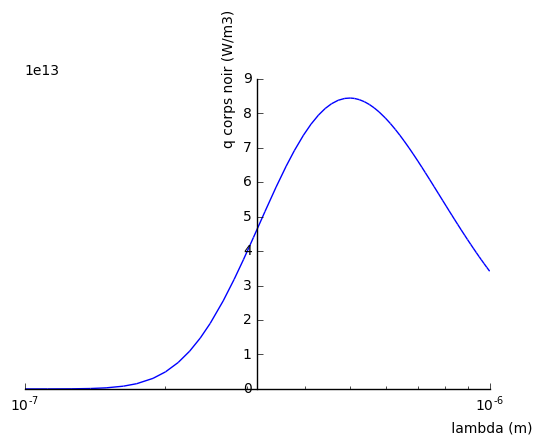

In [30]:
# Le résultat

import sympy as sp
from IPython.display import *
%matplotlib inline
sp.init_printing(use_latex=True)
%matplotlib inline

def planck(T,lam):
    h=6.62608e-34
    k=1.38066e-23
    c=2.99792e8
    P1=2*sp.pi*c**2*h
    P2=lam**5
    P3=sp.exp(c*h/lam/k/T)-1
    return P1/P2/P3
lam=sp.symbols('lam')
sp.plot(planck(5800,lam),(lam,100e-9,1000e-9),ylabel='q corps noir (W/m3)',
        xlabel=' lambda (m)',xscale='log')

La fonction python est définie simplement en utilisant le mot def suivi des arguments comme : 
##### def planck(T,lam):

Les deux points à la fin déterminent le début de la fonction et la fin du décalage sa fin. Si la fonction doit retourner une valeur, le **return** le fait.

Le graphe suivant montre qu'en fait, **sp.plot** utilise la fonction symbolique pour générer des nombres et se base sur ces nombres pour fixer les limites.  

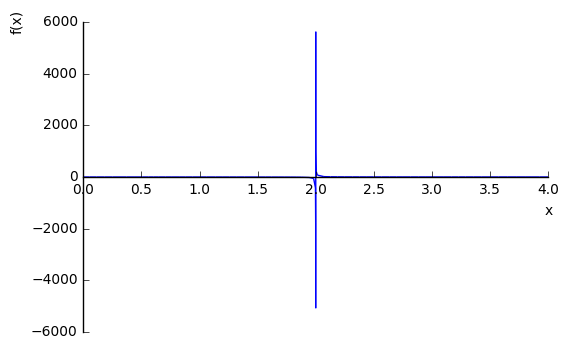

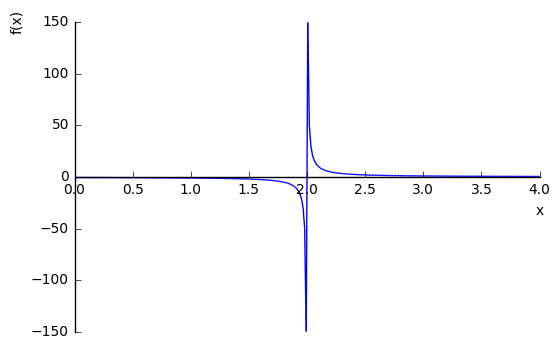

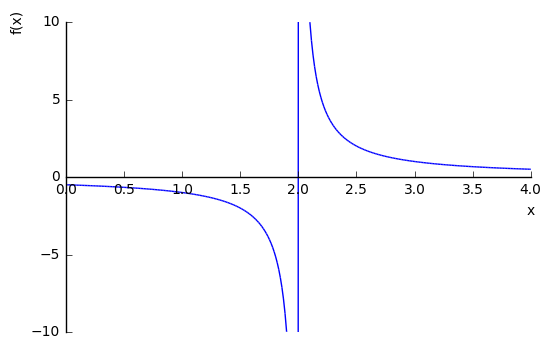

In [31]:
x = sp.symbols('x')
 
# Range non fixé dans la direction y. options par default
sp.plot(1/(x - 2), (x, 0, 4))

# Range non fixé dans la direction y, mais l'algorithme de calcul
# n'adapte pas les intervalles pour mieux couvrir la fonction. 
# adaptive = False donne des intervalles fixes.

sp.plot(1/(x - 2), (x, 0, 4),adaptive=False)
 
# On peut améliorer en changeant les limites de l'affichage en y.
sp.plot(1/(x - 2), (x, 0, 4), ylim=(-10, 10), adaptive=False)

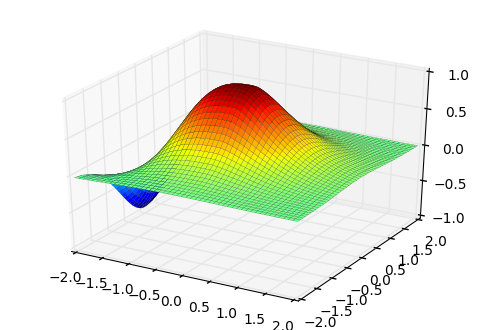

In [32]:
#
# Surface d'une fonction
# 
# Dans ce document on utilise les fonctions de tracage de fonctions
# alors sympy choisit les intervalles et évalue les valeurs de la
# fonction sur les points choisis. Comme vu dans l'exemple précédent
# il choisit par défaut d'adapter le choix des points x et y
#  (adaptive=True), par défaut
#
import sympy as sp
from sympy.plotting import plot3d
#
#
%matplotlib inline
# la commande ci-dessus doit être utilisée si les graphes n'apparaissent
# pas dans le document notebook mais dans des fenetres externes.
#
#
x,y=sp.symbols('x y')
plot3d((sp.exp(-(x**1.5+y**2))),(x,-2,2),(y,-2,2))

Voyons finalement un bel exemple assez complet de tracage d'une fonction démo tiré de matplotlib. Cet exemple démontre assez bien les capacités de matplotlib, La syntaxe et la méthode est encore une fois très près ce ce qu'utilise Matlab.

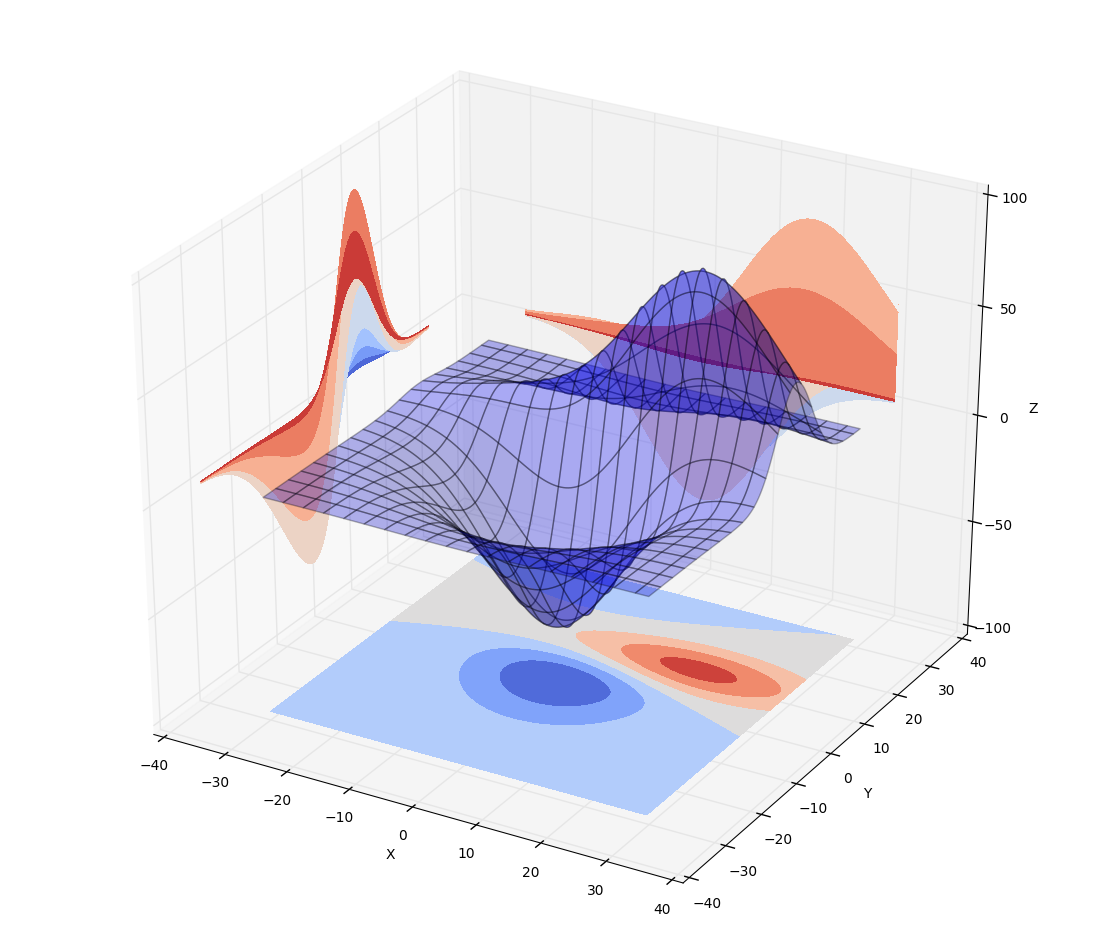

In [33]:
# source:
# http://matplotlib.org/1.3.1/examples/mplot3d/contourf3d_demo2.html

from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline

fig = plt.figure(figsize=(14,12))
ax = fig.gca(projection='3d')
X, Y, Z = axes3d.get_test_data(0.04)
ax.plot_surface(X, Y, Z, rstride=8, cstride=8, alpha=0.3)
cset = ax.contourf(X, Y, Z, zdir='z', offset=-100, cmap=cm.coolwarm)
cset = ax.contourf(X, Y, Z, zdir='x', offset=-40, cmap=cm.coolwarm)
cset = ax.contourf(X, Y, Z, zdir='y', offset=40, cmap=cm.coolwarm)

ax.set_xlabel('X')
ax.set_xlim(-40, 40)
ax.set_ylabel('Y')
ax.set_ylim(-40, 40)
ax.set_zlabel('Z')
ax.set_zlim(-100, 100)

plt.show()